# DepositGuard — Exploratory Data Analysis

EDA on the Bank Account Fraud (NeurIPS 2022) `Base.csv` dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import Markdown, display

plt.style.use('dark_background')
sns.set_palette("bright")

OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Load Data

Numeric columns are downcast to `float32` (with `fraud_bool`/`month` as `int8`) and string columns to `category` to reduce memory footprint.

In [2]:
categorical_cols = ["payment_type", "employment_status", "housing_status", "source", "device_os"]
int8_cols = ["fraud_bool", "month"]

header_cols = pd.read_csv("../data/Base.csv", nrows=0).columns
float32_cols = [c for c in header_cols if c not in categorical_cols and c not in int8_cols]

dtype_map = {col: "category" for col in categorical_cols}
dtype_map.update({col: "int8" for col in int8_cols})
dtype_map.update({col: "float32" for col in float32_cols})

df = pd.read_csv("../data/Base.csv", dtype=dtype_map)
df.head()

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1.0,25.0,40.0,0.006735,102.453712,AA,1059.0,...,0.0,1500.0,0.0,INTERNET,16.224844,linux,1.0,1.0,0.0,0
1,0,0.8,0.617426,-1.0,89.0,20.0,0.010095,-0.849551,AD,1658.0,...,0.0,1500.0,0.0,INTERNET,3.363854,other,1.0,1.0,0.0,0
2,0,0.8,0.996707,9.0,14.0,40.0,0.012316,-1.490386,AB,1095.0,...,0.0,200.0,0.0,INTERNET,22.730558,windows,0.0,1.0,0.0,0
3,0,0.6,0.475100,11.0,14.0,30.0,0.006991,-1.863101,AB,3483.0,...,0.0,200.0,0.0,INTERNET,15.215816,linux,1.0,1.0,0.0,0
4,0,0.9,0.842307,-1.0,29.0,40.0,5.742626,47.152496,AA,2339.0,...,0.0,200.0,0.0,INTERNET,3.743048,other,0.0,1.0,0.0,0


## 1. Shape and Memory Usage

In [3]:
n_rows, n_cols = df.shape
memory_mb = df.memory_usage(deep=True).sum() / 1024**2

print(f"Shape: {n_rows:,} rows x {n_cols} columns")
print(f"Memory usage: {memory_mb:.2f} MB")
print()
print(df.dtypes.value_counts())

Shape: 1,000,000 rows x 32 columns
Memory usage: 102.04 MB

float32     25
int8         2
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64


## 2. Class Distribution

In [4]:
class_counts = df["fraud_bool"].value_counts().sort_index()
class_pct = df["fraud_bool"].value_counts(normalize=True).sort_index() * 100

print(f"Legitimate (0): {class_counts[0]:,} ({class_pct[0]:.3f}%)")
print(f"Fraud (1):      {class_counts[1]:,} ({class_pct[1]:.3f}%)")
print(f"Imbalance ratio: 1:{class_counts[0] / class_counts[1]:.1f}")

Legitimate (0): 988,971 (98.897%)
Fraud (1):      11,029 (1.103%)
Imbalance ratio: 1:89.7


## 3. Fraud Rate by Month

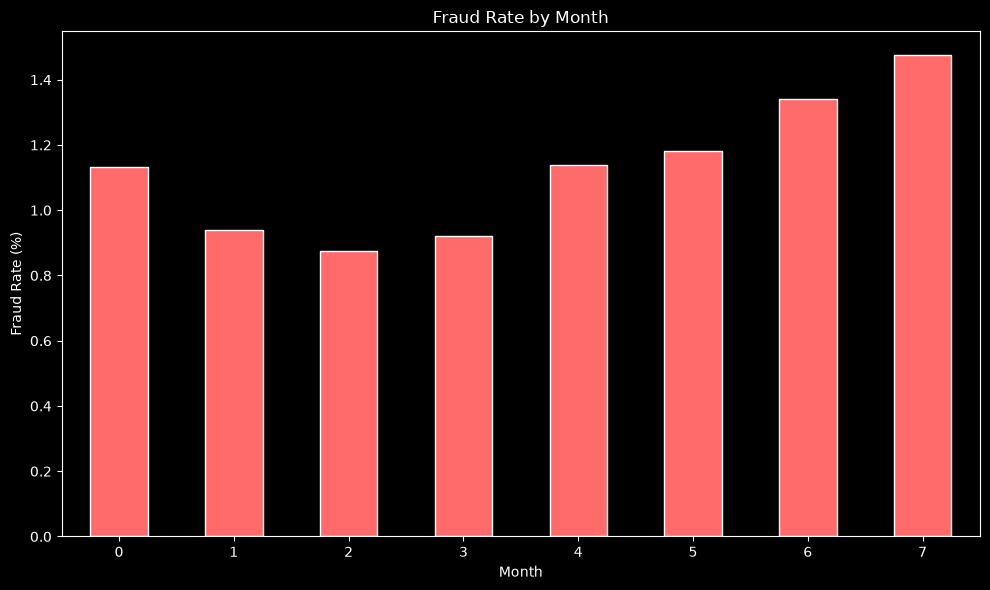

month
0    1.132588
1    0.938724
2    0.874587
3    0.922245
4    1.137120
5    1.182505
6    1.340507
7    1.474552
Name: fraud_bool, dtype: float64

In [5]:
fraud_by_month = df.groupby("month")["fraud_bool"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 6))
fraud_by_month.plot(kind="bar", ax=ax, color="#ff6b6b", edgecolor="white")
ax.set_xlabel("Month")
ax.set_ylabel("Fraud Rate (%)")
ax.set_title("Fraud Rate by Month")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fraud_by_month.png", dpi=150)
plt.show()

fraud_by_month

## 4. Feature Distributions by Fraud Status

`income`, `customer_age`, `credit_risk_score` split by `fraud_bool`.

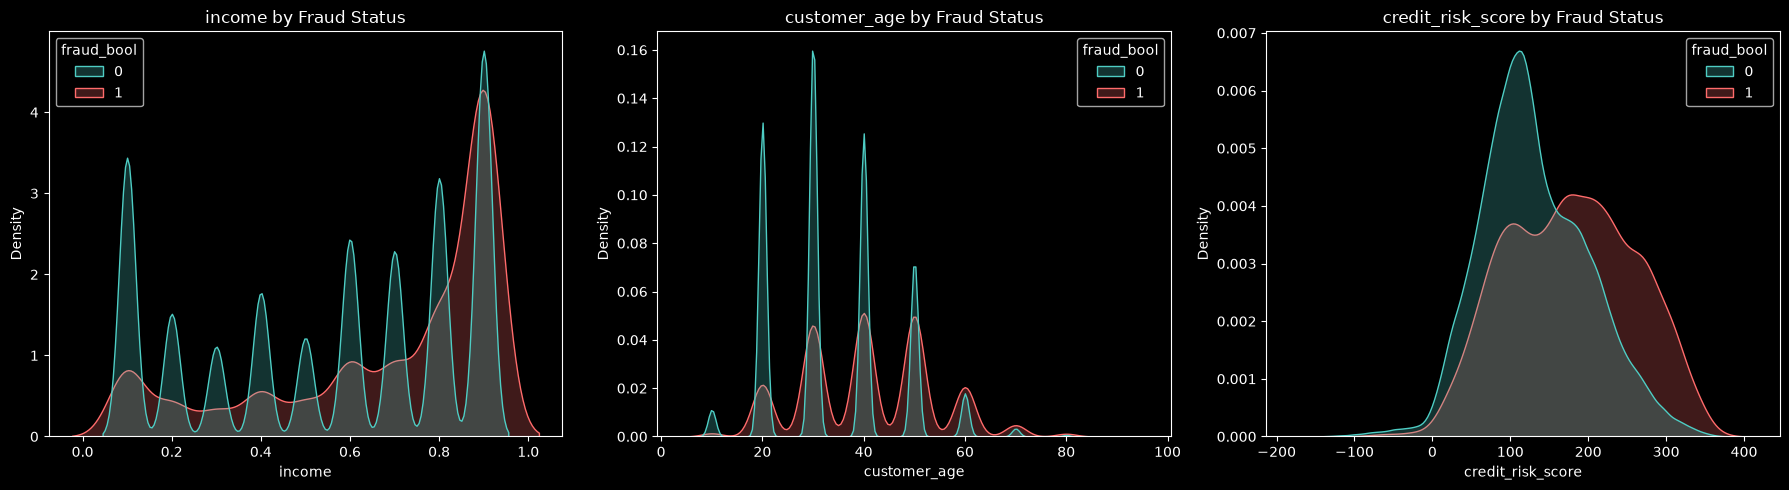

In [6]:
features = ["income", "customer_age", "credit_risk_score"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feature in zip(axes, features):
    sns.kdeplot(
        data=df, x=feature, hue="fraud_bool", fill=True, common_norm=False,
        ax=ax, palette=["#4ecdc4", "#ff6b6b"],
    )
    ax.set_title(f"{feature} by Fraud Status")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_distributions.png", dpi=150)
plt.show()

## 5. Fraud Rate by Categorical Features

`payment_type`, `employment_status`, `housing_status`.

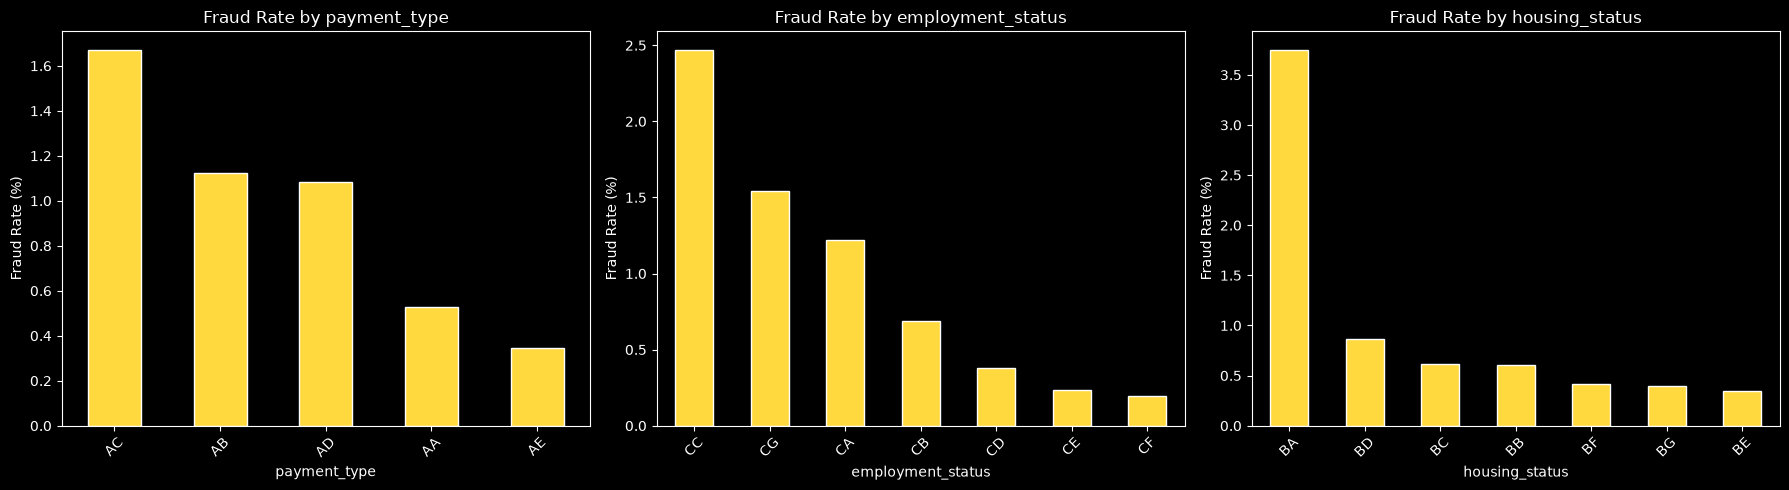

In [7]:
cat_features = ["payment_type", "employment_status", "housing_status"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feature in zip(axes, cat_features):
    rate = (
        df.groupby(feature, observed=True)["fraud_bool"]
        .mean()
        .sort_values(ascending=False) * 100
    )
    rate.plot(kind="bar", ax=ax, color="#ffd93d", edgecolor="white")
    ax.set_ylabel("Fraud Rate (%)")
    ax.set_title(f"Fraud Rate by {feature}")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fraud_by_category.png", dpi=150)
plt.show()

## 6. Correlation Heatmap

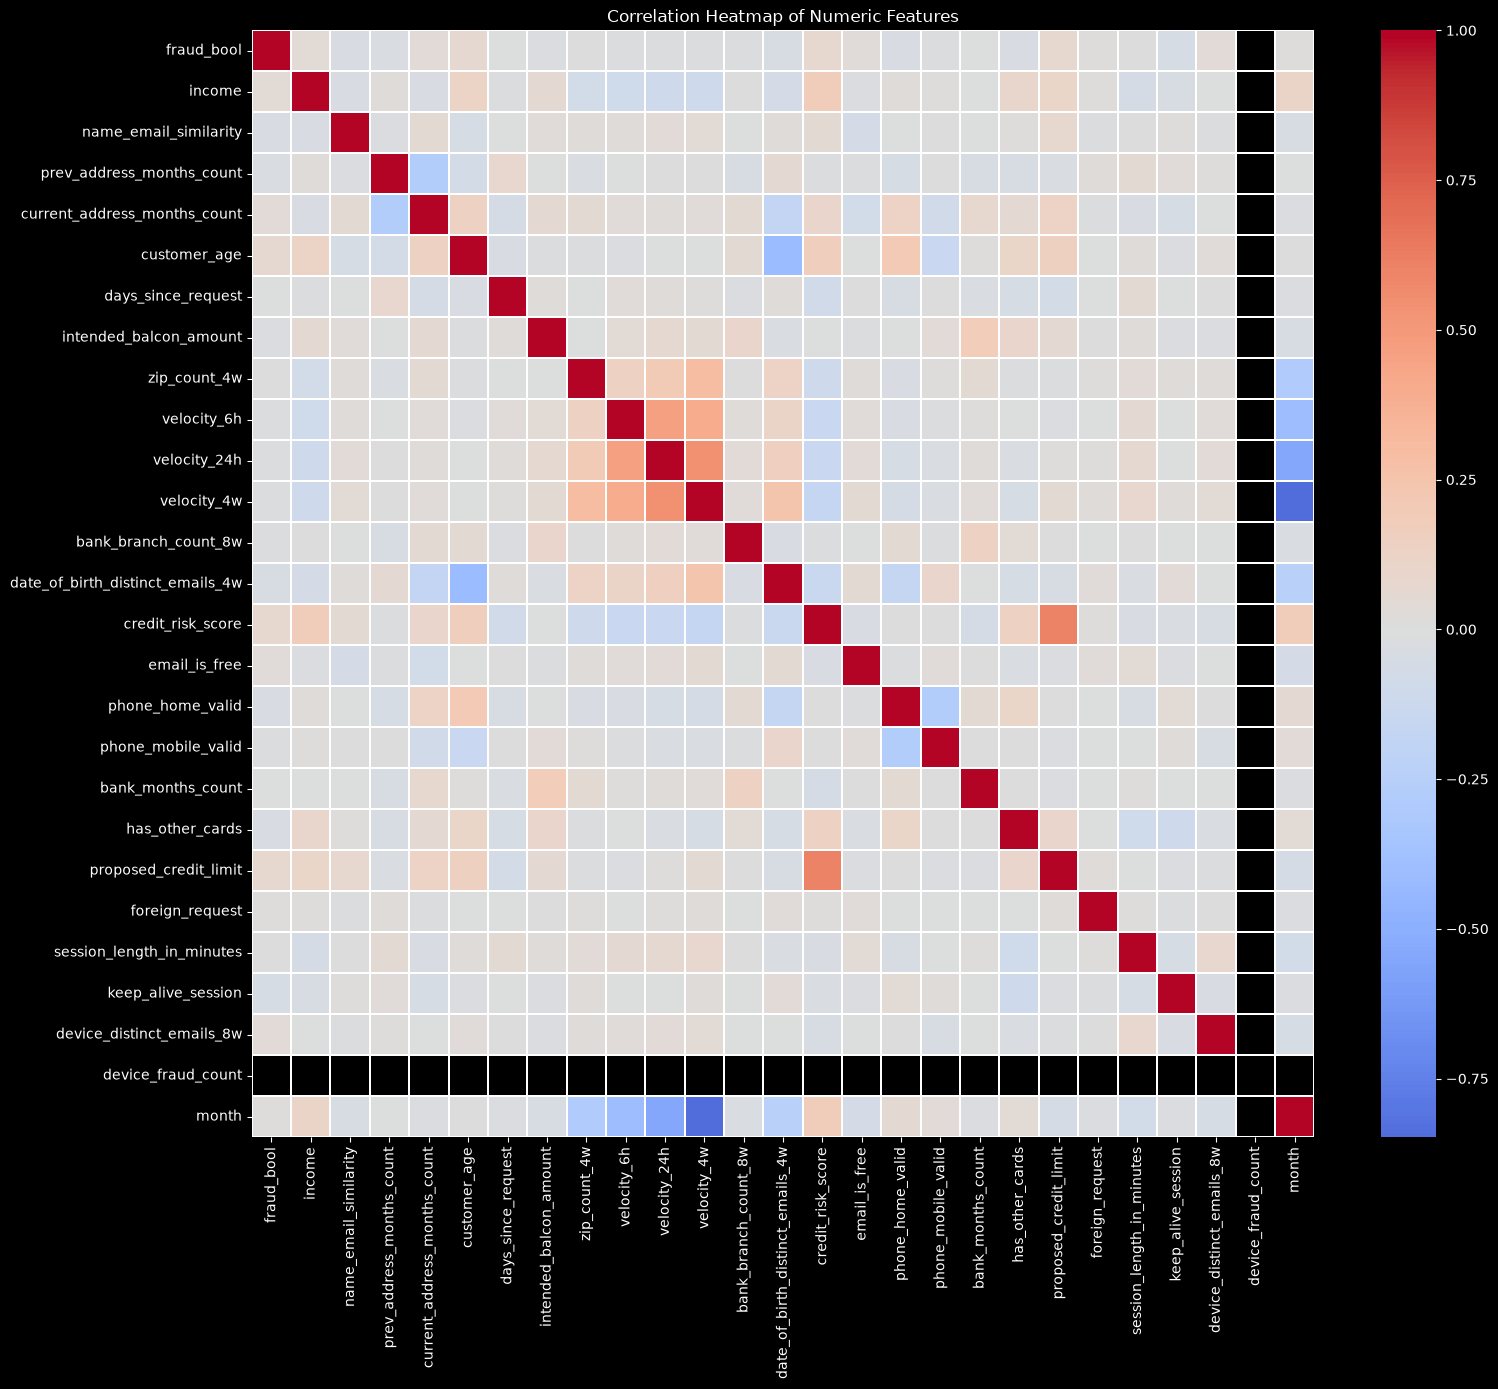

In [8]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3, ax=ax)
ax.set_title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/correlation_heatmap.png", dpi=150)
plt.show()

## 7. Top 5 EDA Findings

In [9]:
fraud_corr = corr["fraud_bool"].drop("fraud_bool").sort_values(key=abs, ascending=False)
top_corr_feature = fraud_corr.index[0]
top_corr_value = fraud_corr.iloc[0]

worst_month = fraud_by_month.idxmax()
worst_month_rate = fraud_by_month.max()
best_month = fraud_by_month.idxmin()
best_month_rate = fraud_by_month.min()

payment_rate = df.groupby("payment_type", observed=True)["fraud_bool"].mean().sort_values(ascending=False) * 100
top_payment = payment_rate.index[0]
top_payment_rate = payment_rate.iloc[0]

employment_rate = df.groupby("employment_status", observed=True)["fraud_bool"].mean().sort_values(ascending=False) * 100
top_employment = employment_rate.index[0]
top_employment_rate = employment_rate.iloc[0]

findings = f"""
1. **Severe class imbalance**: fraud accounts for only {class_pct[1]:.3f}% of applications ({class_counts[1]:,} of {n_rows:,}), a ~1:{class_counts[0] / class_counts[1]:.0f} ratio requiring resampling or class-weighted models.
2. **Fraud rate varies by month**: month {worst_month} has the highest fraud rate ({worst_month_rate:.2f}%) versus month {best_month}, the lowest ({best_month_rate:.2f}%), suggesting temporal drift worth monitoring.
3. **Strongest linear correlate of fraud**: `{top_corr_feature}` has the largest correlation with `fraud_bool` (r = {top_corr_value:.3f}) among numeric features.
4. **Payment type `{top_payment}` shows the highest fraud rate** at {top_payment_rate:.2f}%, notably above other payment types.
5. **Employment status `{top_employment}` is associated with the highest fraud rate** at {top_employment_rate:.2f}%, indicating employment status is a useful risk signal.
"""

display(Markdown(findings))


1. **Severe class imbalance**: fraud accounts for only 1.103% of applications (11,029 of 1,000,000), a ~1:90 ratio requiring resampling or class-weighted models.
2. **Fraud rate varies by month**: month 7 has the highest fraud rate (1.47%) versus month 2, the lowest (0.87%), suggesting temporal drift worth monitoring.
3. **Strongest linear correlate of fraud**: `credit_risk_score` has the largest correlation with `fraud_bool` (r = 0.071) among numeric features.
4. **Payment type `AC` shows the highest fraud rate** at 1.67%, notably above other payment types.
5. **Employment status `CC` is associated with the highest fraud rate** at 2.47%, indicating employment status is a useful risk signal.
